Предположим, что Толя любит авокадо и решил посмотреть динамику цен на данный продукт в США. Имеется следующий набор данных от Hass Avocado Board 🥑:  
•	Date — дата  
•	AveragePrice — средняя цена одного авокадо  
•	Total Volume — количество проданных авокадо  
•	4046 — количество проданных авокадо PLU* 4046  
•	4225 — количество проданных авокадо PLU 4225  
•	4770 — количество проданных авокадо PLU 4770  
•	Total Bags — всего упаковок  
•	Small Bags — маленькие упаковки  
•	Large Bags — большие  
•	XLarge Bags — очень большие  
•	type — обычный или органический  
•	year — год  
•	Region — город или регион the city or region of the observation  
•	*PLU — код товара (Product Lookup code)  

In [3]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

В датафрейме находятся данные не за каждый день, а за конец каждой недели. Для каждой даты есть несколько наблюдений, отличающихся по типу авокадо и региону продажи. Предположим, что нас это разделение не интересует, поэтому в avocado_mean записаны агрегированные данные.

In [4]:
avocado_mean = pd.read_csv(r'C:\Users\PC\Desktop\Софт\Simulation\Simulation\data\6_avocado_mean.csv', index_col=0, parse_dates=['Date'])

In [5]:
avocado_mean.head()

,AveragePrice
Date,
2015-01-04,1.301296
2015-01-11,1.370648
2015-01-18,1.391111
2015-01-25,1.397130
2015-02-01,1.247037


In [ ]:
avocado_mean.info()

In [ ]:
avocado_mean.describe(include='all')

Посчитайте скользящее среднее цены авокадо (AveragePrice) с окном равным 3 (window). Чему равно максимальное значение? Ответ округлите до 2 знаков после точки.

In [11]:
rm = avocado_mean.rolling(window=3).mean()

In [ ]:
np.round(rm.max(), 2)

Построить графики скользящего среднего с разными значениями параметра window (2, 4, 10, 50), 

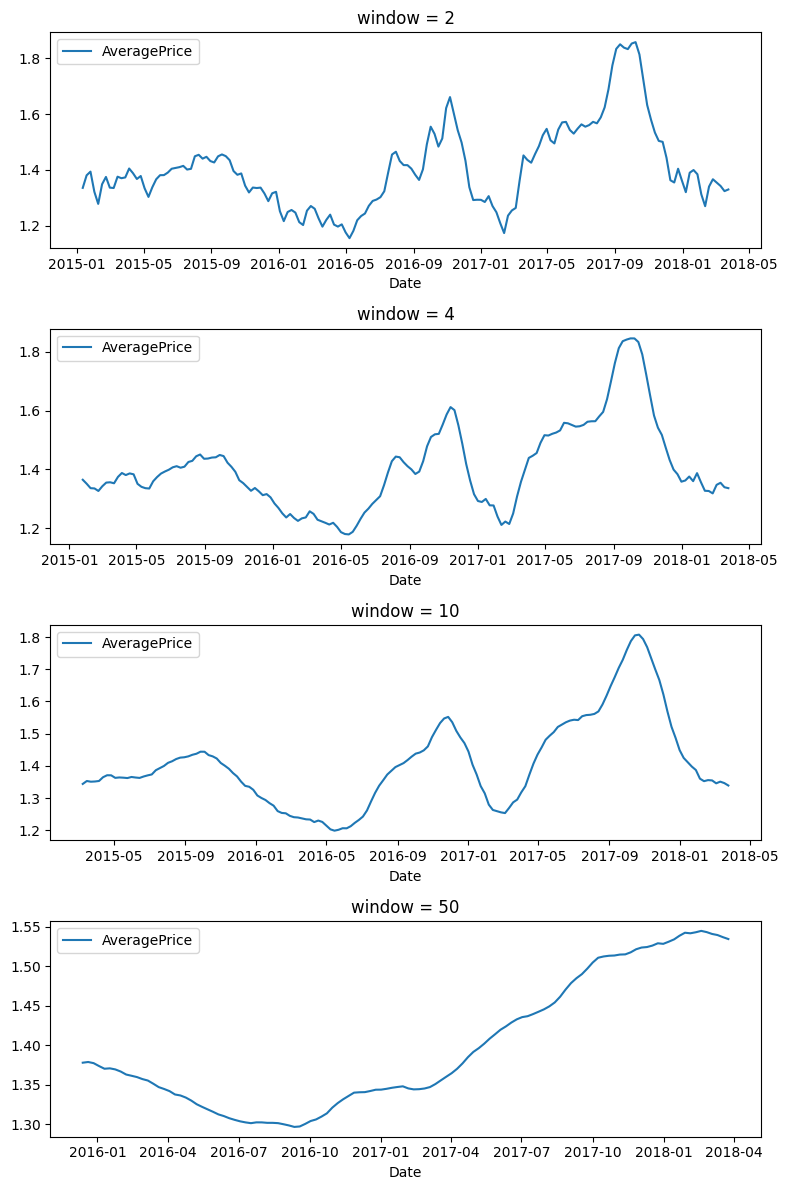

In [14]:
windows = [2, 4, 10, 50]
fig, axes = plt.subplots(4, 1, figsize=(8, 12))
for i, window in enumerate(windows):
    df = avocado_mean.rolling(window=window).mean()
    sns.lineplot(data=df, ax=axes[i])
    axes[i].set_title(f'window = {window}')
plt.tight_layout()

Используйте агрегированные данные о ценах на авокадо и примените функцию ewm() с параметром span=2, чтобы получить экспоненциальное скользящее среднее. Запишите результат в avocado_ewm.

In [17]:
avocado_ewm = avocado_mean.ewm(span=2).mean()

И еще одно задание, чтобы закрепить материал. Импортируйте полные данные, указав index_col=0 (использовать первую колонку как индекс).  
Для авокадо типа organic (type) в Чикаго (region) посчитайте скользящее среднее с окном 4 и экспоненциальное скользящее среднее с параметром span=4. Постройте графики, а затем заполните пропуски. Числа округлите до трех знаков после точки.

In [18]:
avocado_full = pd.read_csv(r'C:\Users\PC\Desktop\Софт\Simulation\Simulation\data\6_avocado_full.csv', index_col=0, parse_dates=['Date'])

In [19]:
avocado_full.head()

,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
Date,,,,,,,,,,,,
2015-01-04,1.75,27365.89,9307.34,3844.81,615.28,13598.46,13061.10,537.36,0.0,organic,2015,Southeast
2015-01-04,1.49,17723.17,1189.35,15628.27,0.00,905.55,905.55,0.00,0.0,organic,2015,Chicago
2015-01-04,1.68,2896.72,161.68,206.96,0.00,2528.08,2528.08,0.00,0.0,organic,2015,HarrisburgScranton
2015-01-04,1.52,54956.80,3013.04,35456.88,1561.70,14925.18,11264.80,3660.38,0.0,conventional,2015,Pittsburgh
2015-01-04,1.64,1505.12,1.27,1129.50,0.00,374.35,186.67,187.68,0.0,organic,2015,Boise


In [ ]:
avocado_full.info()

In [ ]:
avocado_full.describe(include='all')

In [33]:
organic_ch = avocado_full.loc[(avocado_full['type']=='organic')&(avocado_full['region']=='Chicago')]

In [ ]:
organic_ch.rolling(window=4).mean()

In [ ]:
organic_ch.ewm(span=4).mean()

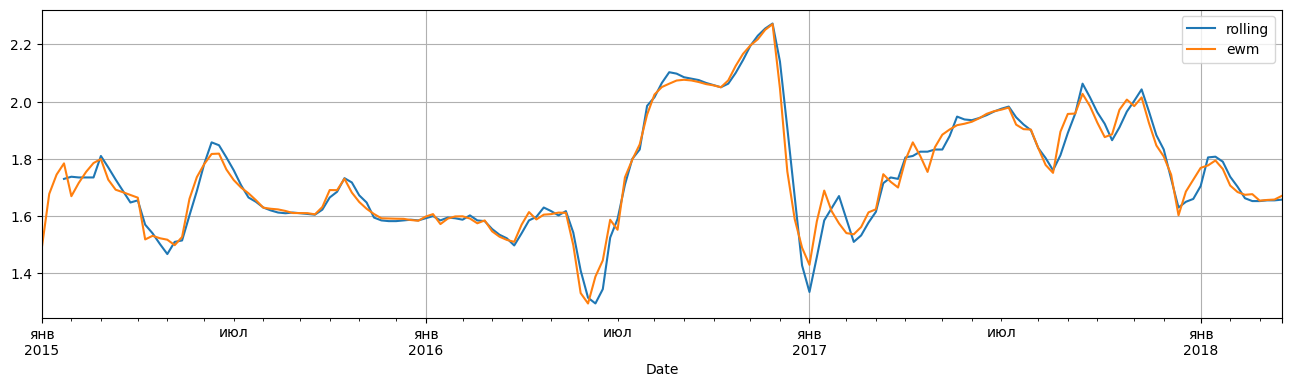

In [34]:
fig, ax = plt.subplots(figsize=(16, 4))
organic_ch.AveragePrice.rolling(window=4).mean().plot(ax=ax, label='rolling')
organic_ch.AveragePrice.ewm(span=4).mean().plot(ax=ax, label='ewm')
plt.legend()
plt.grid()

Прочитайте эти данные. Далее переведите delay в timedelta формат. Обратите внимание, что так просто столбец не переведётся – нужно будет убрать -.  
Могут понадобиться:  
•	pd.to_timedelta()  
•	pd.Series.str  

In [4]:
df = pd.read_csv(r'C:\Users\PC\Desktop\Софт\Simulation\Simulation\data\6_delays.csv')

In [13]:
df.head()

,client_id,company_id,delay,revenue,days,category
0,2389,4240,1 days 14:57:48,705436,1.623472,1-2 days
1,7614,9544,4 days 02:14:23,859266,4.093322,more than 3 days
2,2052,2427,0 days 06:08:57,812416,0.256215,less than 1 day
3,9635,8054,0 days 23:40:19,162312,0.986331,less than 1 day
4,8154,5503,1 days 13:21:53,658844,1.556863,1-2 days


In [6]:
df['delay'] = df['delay'].str.replace('-', '')

In [7]:
df['delay'] = pd.to_timedelta(df.delay)

Время это хорошо, но хотелось бы также разделить его на промежутки. Разбейте соответствующую колонку на 3 интервала и поместите значения в колонку delay_categorical.  
Могут понадобится: pd.cut()

In [68]:
df['delay_categorical'] = pd.cut(df['delay'], bins=3)

Разбилось неплохо, но хочется чуть более целые значения и более человеческие названия. В этом нам помогут аргументы функции pd.cut! Перезадайте колонку delay_categorical, чтобы значения в ней были:  
•	'less than 1 day' – время от 0 до 1 дня  
•	'1-2 days' – от 1 до 2 дней  
•	'2-3 days' – от 2 до 3 дней  
•	 'more than 3 days' – больше 3 дней

In [9]:
df['days'] = df['delay'].dt.total_seconds() / (24 * 3600)

In [11]:
bins = [0, 1, 2, 3, float('inf')]
labels = ['less than 1 day', '1-2 days', '2-3 days', 'more than 3 days']

In [12]:
df['category'] = pd.cut(df['days'], bins=bins, labels=labels, right=True, include_lowest=True)

Теперь постройте интерактивный барплот с тем, насколько часто задерживаются сделки.

<Axes: xlabel='category', ylabel='count'>

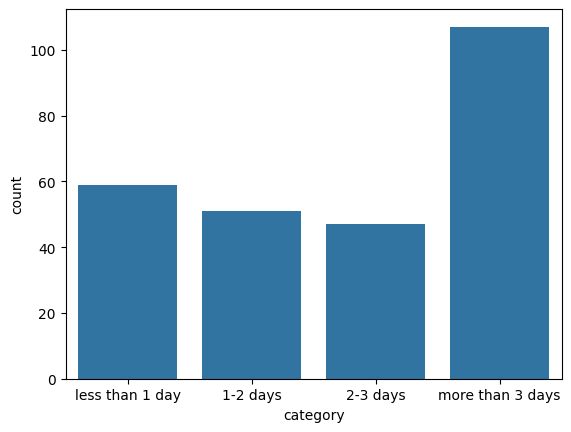

In [14]:
sns.countplot(x='category', data=df)

In [18]:
delay = df.category.value_counts()

In [19]:
px.bar(delay)